In [ ]:
import pandas as pd
import numpy as np

data = pd.read_csv("diabetes_.csv")
print("Original Data:")
print(data.head())

data = data.dropna()
print("\nData after dropping missing values:")
print(data.head())

X = data.drop(columns=['Outcome']).values
y = data['Outcome'].values

print("\nFeatures (X):")
print(X[:5])  # print first 5 rows of features

print("\nTarget (y):")
print(y[:5])  # print first 5 values of target


Original Data:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Data after dropping missing values:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183            

In [ ]:
def train_test_split_scratch(X, y, test_size=0.3, random_seed=42):
    np.random.seed(random_seed)
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    test_split_size = int(len(X) * test_size)
    test_indices = indices[:test_split_size]
    train_indices = indices[test_split_size:]
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = train_test_split_scratch(X, y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(538, 8) (230, 8) (538,) (230,)


In [ ]:
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

def knn_predict_single(query, X_train, y_train, k=3):
    distances = [euclidean_distance(query, x) for x in X_train]
    nearest_indices = np.argsort(distances)[:k]
    nearest_labels = y_train[nearest_indices]
    return np.bincount(nearest_labels).argmax()

def knn_predict(X_test, X_train, y_train, k=3):
    return np.array([knn_predict_single(x, X_train, y_train, k) for x in X_test])

def compute_accuracy(y_true, y_pred):
    return (np.sum(y_true == y_pred) / len(y_true)) * 100

predictions = knn_predict(X_test, X_train, y_train, k=3)
accuracy = compute_accuracy(y_test, predictions)
print(f"Accuracy (original dataset): {accuracy:.2f}%")


Accuracy (original dataset): 67.39%


In [39]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = scaler.fit_transform(X)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split_scratch(X_scaled, y)

predictions_scaled = knn_predict(X_test_s, X_train_s, y_train_s, k=3)
accuracy_scaled = compute_accuracy(y_test_s, predictions_scaled)
print(f"Accuracy (scaled dataset): {accuracy_scaled:.2f}%")

Accuracy (scaled dataset): 70.87%


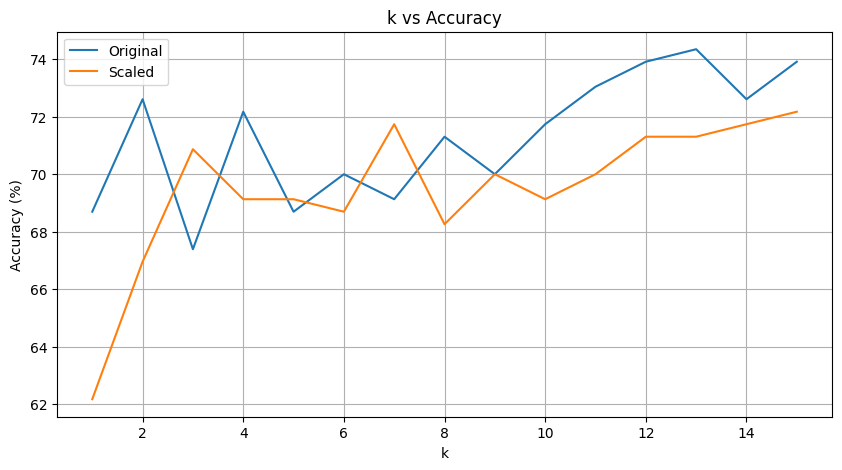

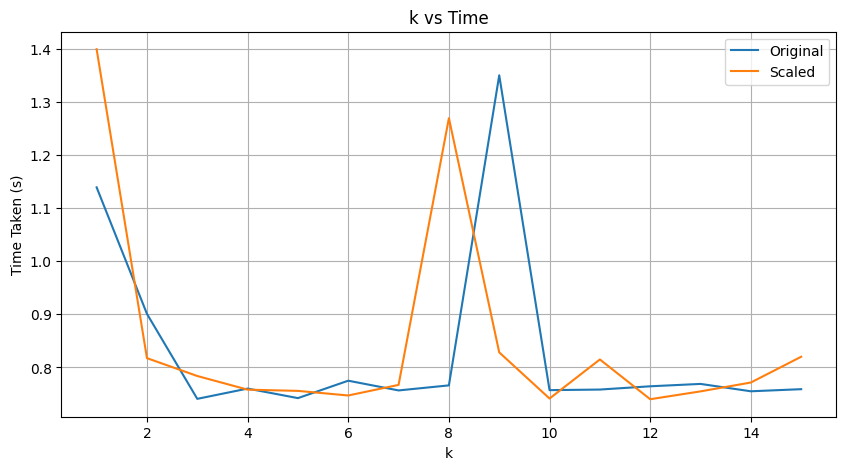

In [ ]:
import matplotlib.pyplot as plt
import time

k_values = range(1, 16)
accuracies_orig = []
accuracies_scaled = []
times_orig = []
times_scaled = []

for k in k_values:
    start = time.time()
    pred = knn_predict(X_test, X_train, y_train, k=k)
    times_orig.append(time.time() - start)
    accuracies_orig.append(compute_accuracy(y_test, pred))

    start = time.time()
    pred_s = knn_predict(X_test_s, X_train_s, y_train_s, k=k)
    times_scaled.append(time.time() - start)
    accuracies_scaled.append(compute_accuracy(y_test_s, pred_s))

plt.figure(figsize=(10,5))
plt.plot(k_values, accuracies_orig, label="Original")
plt.plot(k_values, accuracies_scaled, label="Scaled")
plt.xlabel("k")
plt.ylabel("Accuracy (%)")
plt.title("k vs Accuracy")
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(10,5))
plt.plot(k_values, times_orig, label="Original")
plt.plot(k_values, times_scaled, label="Scaled")
plt.xlabel("k")
plt.ylabel("Time Taken (s)")
plt.title("k vs Time")
plt.legend()
plt.grid(True)
plt.show()





